# Лабораторная работа №4: Кластеризация

## Задание 1

**Условие задачи:**

Сгенерируйте синтетический датасет с помощью функции `make_blobs` из
библиотеки `sklearn.datasets`. Параметры генерации: количество объектов 500,
количество кластеров 4, стандартное отклонение 1.0, `random_state=42` (для
воспроизводимости).

Выполните задания:
1. Постройте точечный график (`scatter plot`) сгенерированных данных, раскрасив
точки в соответствии с истинными метками кластеров.
2. Примените алгоритм k-means с параметром `n_clusters` = 4. Визуализируйте
результат кластеризации: точки, раскрашенные в цвета предсказанных кластеров, и
центры полученных кластеров.
3. Вычислите `WCSS` и силуэтный коэффициент
4. Постройте график метода "локтя" для значений `k` от 2 до 8. Определите оптимальное количество кластеров по этому методу.


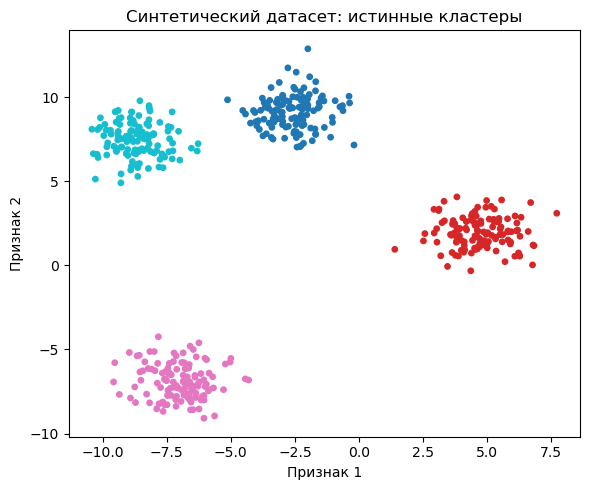

C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


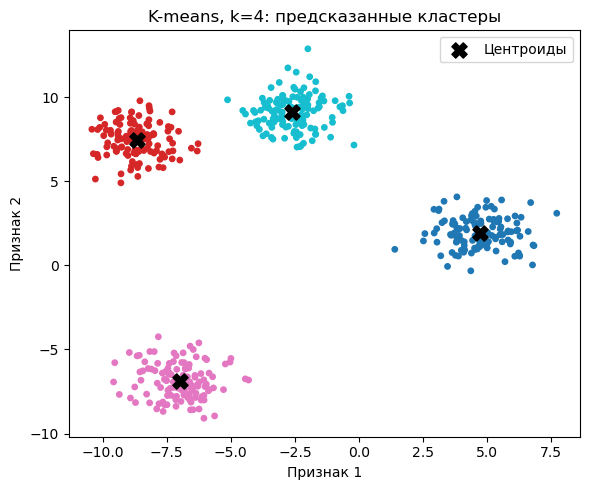

Задание 1: k=4
WCSS = 948.890
Силуэтный коэффициент = 0.791


C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

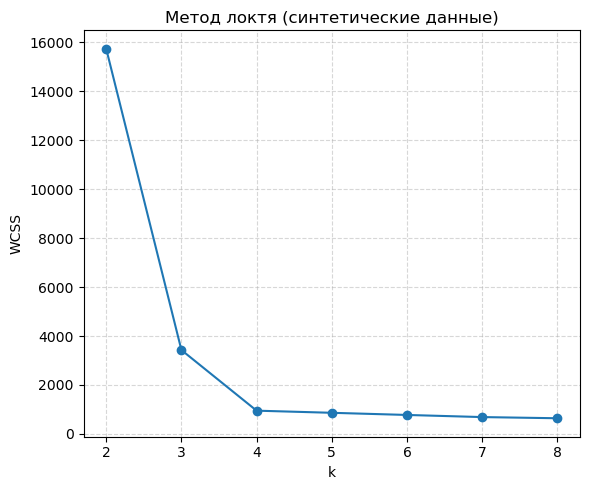

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Генерация данных
X, y_true = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

# 1.1. Scatter по истинным меткам
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='tab10', s=15)
plt.title("Синтетический датасет: истинные кластеры")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.tight_layout()
plt.show()

# 2. KMeans с k=4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init="auto")
y_pred_4 = kmeans_4.fit_predict(X)
centers_4 = kmeans_4.cluster_centers_

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_pred_4, cmap='tab10', s=15)
plt.scatter(centers_4[:, 0], centers_4[:, 1],
            c='black', s=120, marker='X', label='Центроиды')
plt.title("K-means, k=4: предсказанные кластеры")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.legend()
plt.tight_layout()
plt.show()

# 3. WCSS и силуэт
wcss_4 = kmeans_4.inertia_
sil_4 = silhouette_score(X, y_pred_4)

print(f"Задание 1: k=4")
print(f"WCSS = {wcss_4:.3f}")
print(f"Силуэтный коэффициент = {sil_4:.3f}")

# 4. Метод локтя для k=2..8
k_values = range(2, 9)
wcss_list = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X)
    wcss_list.append(km.inertia_)

plt.figure(figsize=(6, 5))
plt.plot(k_values, wcss_list, marker='o')
plt.title("Метод локтя (синтетические данные)")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.xticks(list(k_values))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Задание 2

**Условие задачи:**

Используйте тот же синтетический датасет, что и в Задании 1. Выполните
следующие пункты:
1. Примените алгоритм k-means для значений k = 2, 3, 4, 5, 6, 7, 8.
2. Для каждого значения k вычислите: сумму квадратов расстояний
(`WCSS`), силуэтный коэффициент
3. Постройте два графика на одном поле:
3.1 График зависимости `WCSS` от `k` (метод локтя)
3.2 График зависимости силуэтного коэффициента от `k`
4. Сделайте вывод: какое значение `k` является оптимальным с точки зрения
каждого метода? Совпадают ли результаты?

C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

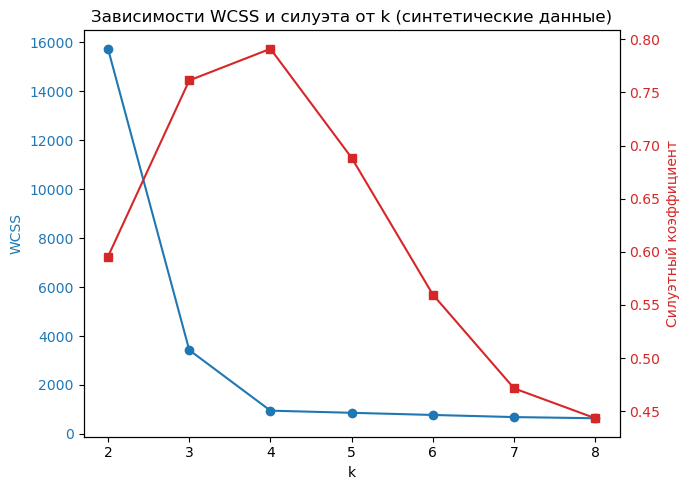

k=2: WCSS=15737.08, силуэт=0.596
k=3: WCSS=3426.26, силуэт=0.761
k=4: WCSS=948.89, силуэт=0.791
k=5: WCSS=861.76, силуэт=0.688
k=6: WCSS=773.66, силуэт=0.560
k=7: WCSS=686.85, силуэт=0.471
k=8: WCSS=639.01, силуэт=0.443


In [9]:
from sklearn.metrics import silhouette_score

# Предполагаем, что X уже сгенерирован в Задании 1

k_values = range(2, 9)
wcss_list = []
sil_list = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    wcss_list.append(km.inertia_)
    
    # Силуэт имеет смысл только для k >= 2, но мы начинаем с 2, так что норм
    sil = silhouette_score(X, labels)
    sil_list.append(sil)

# Два графика на одном поле (две оси Y)
fig, ax1 = plt.subplots(figsize=(7, 5))

color1 = 'tab:blue'
ax1.set_xlabel('k')
ax1.set_ylabel('WCSS', color=color1)
ax1.plot(k_values, wcss_list, marker='o', color=color1, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Силуэтный коэффициент', color=color2)
ax2.plot(k_values, sil_list, marker='s', color=color2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Зависимости WCSS и силуэта от k (синтетические данные)")
fig.tight_layout()
plt.show()

for k, w, s in zip(k_values, wcss_list, sil_list):
    print(f"k={k}: WCSS={w:.2f}, силуэт={s:.3f}")

- С точки зрения метода локтя оптимальное значение k ≈ 4.

- С точки зрения силуэтного коэффициента оптимальное значение k = 4 (максимальный силуэт).

- Результаты совпадают: оба метода указывают на k = 4 как на наиболее подходящее число кластеров для синтетического датасета.

## Задание 3

**Условие задачи:**

Выберите датасет из приложения в соответствии с результатом:
(номер_вашего_варианта % 15 + 1)
`25 % 15 + 1 = 11`
Для выбранного датасета выполните следующие
пункты:
1. Загрузите датасет и выделите два признака, указанных в приложении, в
матрицу X, а истинные метки классов — в вектор `y_true`.
2. Выполните Z-масштабирование (нормализацию) признаков с помощью
`StandardScaler`. Объясните, почему для кластеризации k-means это необходимо.
3. Постройте точечный график (`scatter plot`) исходных данных, раскрасив
точки в соответствии с истинными классами.
4. Примените алгоритм k-means с параметром `n_clusters`, равным
количеству истинных классов в датасете. Визуализируйте результат кластеризации.
5. Вычислите и интерпретируйте: силуэтный коэффициент, `WCSS`
6. Постройте график метода "локтя" для значений k от 2 до 10. Определите
оптимальное количество кластеров по этому методу.
7. Сравните оптимальное количество кластеров, полученное методом
"локтя", с количеством истинных классов. Объясните полученное расхождение
(если оно есть).


         0     1        2      3    4    5    6       7         8         9   \
0  19910108  X126  TVGUIDE  25503  YES  KEY  YES  BENTON  GALLATIN  UNCOATED   
1  19910109  X266  TVGUIDE  25503  YES  KEY  YES  BENTON  GALLATIN  UNCOATED   
2  19910104    B7   MODMAT  47201  YES  KEY  YES  BENTON  GALLATIN  UNCOATED   
3  19910104  T133   MASSEY  39039  YES  KEY  YES  BENTON  GALLATIN  UNCOATED   
4  19910111   J34    KMART  37351   NO  KEY  YES  BENTON  GALLATIN  UNCOATED   

   ...    30 31 32   33   34  35  36      37   38      39  
0  ...  36.4  0  0  2.5    1  34  40     105  100    band  
1  ...  38.5  0  0  2.5  0.7  34  40     105  100  noband  
2  ...  39.8  0  0  2.8  0.9  40  40  103.87  100  noband  
3  ...  38.8  0  0  2.5  1.3  40  40  108.06  100  noband  
4  ...  42.5  5  0  2.3  0.6  35  40  106.67  100  noband  

[5 rows x 40 columns]
Число истинных классов: 2
Форма X: (277, 2)
Уникальные классы y_true: [0 1]


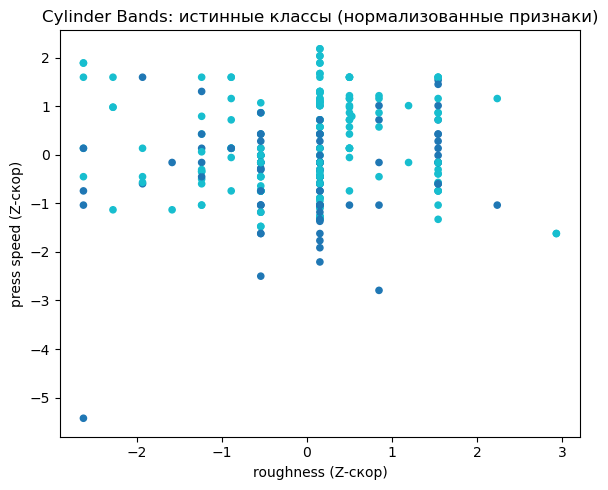

C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


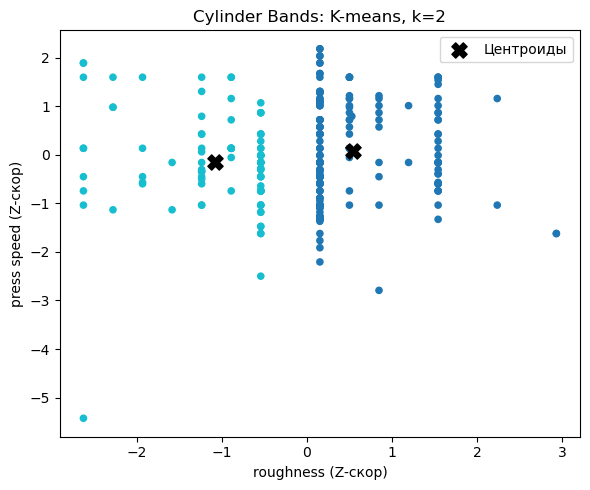

C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\zlata\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

Задание 3: k=2
WCSS = 388.294
Силуэтный коэффициент = 0.316


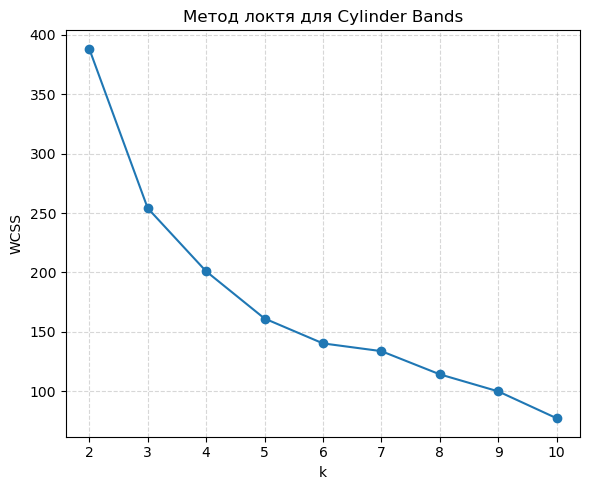

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Загрузка датасета Cylinder Bands из UCI ML Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/cylinder-bands/bands.data"
data = pd.read_csv(url, header=None)

# Быстрый взгляд на первые строки
print(data.head())

# Заменяем '?' на NaN и выбрасываем строки с пропусками
data = data.replace("?", np.nan)
data = data.dropna()

# Преобразуем нужные столбцы к float / категориальному типу
# 26-й столбец (индекс 25) — roughness
# 29-й столбец (индекс 28) — press speed
# 40-й столбец (индекс 39) — band type (band / noband)

data.iloc[:, 25] = data.iloc[:, 25].astype(float)
data.iloc[:, 28] = data.iloc[:, 28].astype(float)

# X: два числовых признака
X = data.iloc[:, [25, 28]].values

# y_true: переведём band/noband в числа 0/1
y_true = data.iloc[:, 39].astype('category').cat.codes.values
n_classes = len(np.unique(y_true))
print("Число истинных классов:", n_classes)

print("Форма X:", X.shape)
print("Уникальные классы y_true:", np.unique(y_true))

# 2. Z-масштабирование (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Объяснение, почему это важно для k-means:
# потому что алгоритм k-means основан на евклидовом расстоянии,
# и признаки с большим масштабом начинают доминировать; нормализация
# приводит признаки к одному масштабу (среднее 0, дисперсия 1).[file:1]

# 3. Scatter по истинным классам (в нормализованных координатах)
plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap='tab10', s=20)
plt.title("Cylinder Bands: истинные классы (нормализованные признаки)")
plt.xlabel("roughness (Z-скор)")
plt.ylabel("press speed (Z-скор)")
plt.tight_layout()
plt.show()

# 4. KMeans с k = числу истинных классов
kmeans_real = KMeans(n_clusters=n_classes, random_state=42, n_init="auto")
y_pred = kmeans_real.fit_predict(X_scaled)
centers = kmeans_real.cluster_centers_

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred, cmap='tab10', s=20)
plt.scatter(centers[:, 0], centers[:, 1],
            c='black', s=120, marker='X', label='Центроиды')
plt.title(f"Cylinder Bands: K-means, k={n_classes}")
plt.xlabel("roughness (Z-скор)")
plt.ylabel("press speed (Z-скор)")
plt.legend()
plt.tight_layout()
plt.show()

# 5. WCSS и силуэт
wcss_real = kmeans_real.inertia_
sil_real = silhouette_score(X_scaled, y_pred)

print(f"Задание 3: k={n_classes}")
print(f"WCSS = {wcss_real:.3f}")
print(f"Силуэтный коэффициент = {sil_real:.3f}")

# 6. Метод локтя для k=2..10
k_range = range(2, 11)
wcss_range = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    wcss_range.append(km.inertia_)

plt.figure(figsize=(6, 5))
plt.plot(k_range, wcss_range, marker='o')
plt.title("Метод локтя для Cylinder Bands")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- По методу «локтя» оптимальное количество кластеров можно выбрать как k=4: именно в районе k=4 заметно меняется характер падения WCSS, дальше прирост качества при увеличении k становится существенно меньше.

- Истинное количество классов в датасете равно 2 (band / noband), поэтому метод локтя даёт значение k=4, которое не совпадает с истинным числом классов.